# PageRank on the Citation Graph

In this notebook we implement and run the PageRank algorithm over our synthetic citation network.
We will:
- Load the citation mappings (outgoing, incoming)
- Implement iterative PageRank
- Observe convergence
- Rank papers by authority score
- Visualize the network with node sizes proportional to PageRank


## Load Citation Graph

Load outgoing_dict.json and incoming_dict.json (from assets/ or index notebook).

Build a networkx.DiGraph.

In [1]:
import json, os, networkx as nx, numpy as np, matplotlib.pyplot as plt

with open("assets/outgoing_dict.json") as f:
    outgoing_dict = json.load(f)
with open("assets/incoming_dict.json") as f:
    incoming_dict = json.load(f)

# Build directed graph
G = nx.DiGraph()
for src, refs in outgoing_dict.items():
    for tgt in [t.strip() for t in refs.split(",") if t.strip()]:
        G.add_edge(src, tgt)
print("Graph loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")


Graph loaded: 20 nodes, 53 edges


## Page Rank

## Q3: Given the incoming and outgoing dictionary, implement iterative page rank algorithm

In [2]:
def pagerank(incoming_dict, outgoing_dict, d=0.85, max_iter=100, tol=1e-6):
    """
    Compute PageRank scores for all papers.
    d = damping factor

    returns page rank scores in a dictionary format:

    pr: {node, page_rank_score}
    """
    nodes = list(outgoing_dict.keys())
    N = len(nodes)
    pr = {node: 1.0/N for node in nodes} # uniform initialization

    '''
    type your code here.
    '''
    for i in range(max_iter):
        next_pr = {node: (1 - d) / N for node in nodes}
        for node, score in pr.items():
            incoming_nodes = incoming_dict[node].split(", ") if node in incoming_dict else [] 
            for incoming_node in incoming_nodes:
                next_pr[node] += d * (pr[incoming_node] / len(outgoing_dict[incoming_node].split(", ")))

        convergence_diff = sum([abs(next_pr[node] - pr[node]) for node in nodes])
        pr = next_pr
        if convergence_diff < tol:
            break
            
    return pr

# Run PageRank
pr_scores = pagerank(incoming_dict, outgoing_dict)


In [3]:
# Save for reuse
scores_path = os.path.join("assets", "pagerank_scores.json")
with open(scores_path, "w", encoding="utf-8") as f:
    json.dump(pr_scores, f, indent=2)
print(f"Processed docs saved to {scores_path}")

Processed docs saved to assets/pagerank_scores.json


In [4]:
ranked = sorted(pr_scores.items(), key=lambda x: x[1], reverse=True)
print("Top 10 papers by PageRank:")
for pid, score in ranked[:20]:
    print(f"{pid}: {score:.4f}")


Top 10 papers by PageRank:
Paper18: 0.1263
Paper2: 0.0899
Paper16: 0.0770
Paper8: 0.0722
Paper4: 0.0658
Paper20: 0.0649
Paper11: 0.0507
Paper13: 0.0502
Paper9: 0.0497
Paper5: 0.0493
Paper14: 0.0474
Paper3: 0.0456
Paper19: 0.0379
Paper15: 0.0372
Paper17: 0.0351
Paper1: 0.0269
Paper6: 0.0229
Paper12: 0.0219
Paper7: 0.0215
Paper10: 0.0075


## Q3(a): OBSERVATION 
#### (which node has the highest vs the lowest page rank? How does chanding the value of d - dampening factor changed these ranks?  )
-
###### type here
Paper 18 has the highest page rank while paper 10 has the lowest page rank. Increasing the dampening factor towards 1 can make the score difference bigger with page 10 having a score of 0 while decreasing it towards 0 causes the score difference to be smaller where every paper will have the same score when it hits 0. Generally, page 18 and page 10 does not change but some papers in the middle scores have moved around when the dampening factor is changed. 

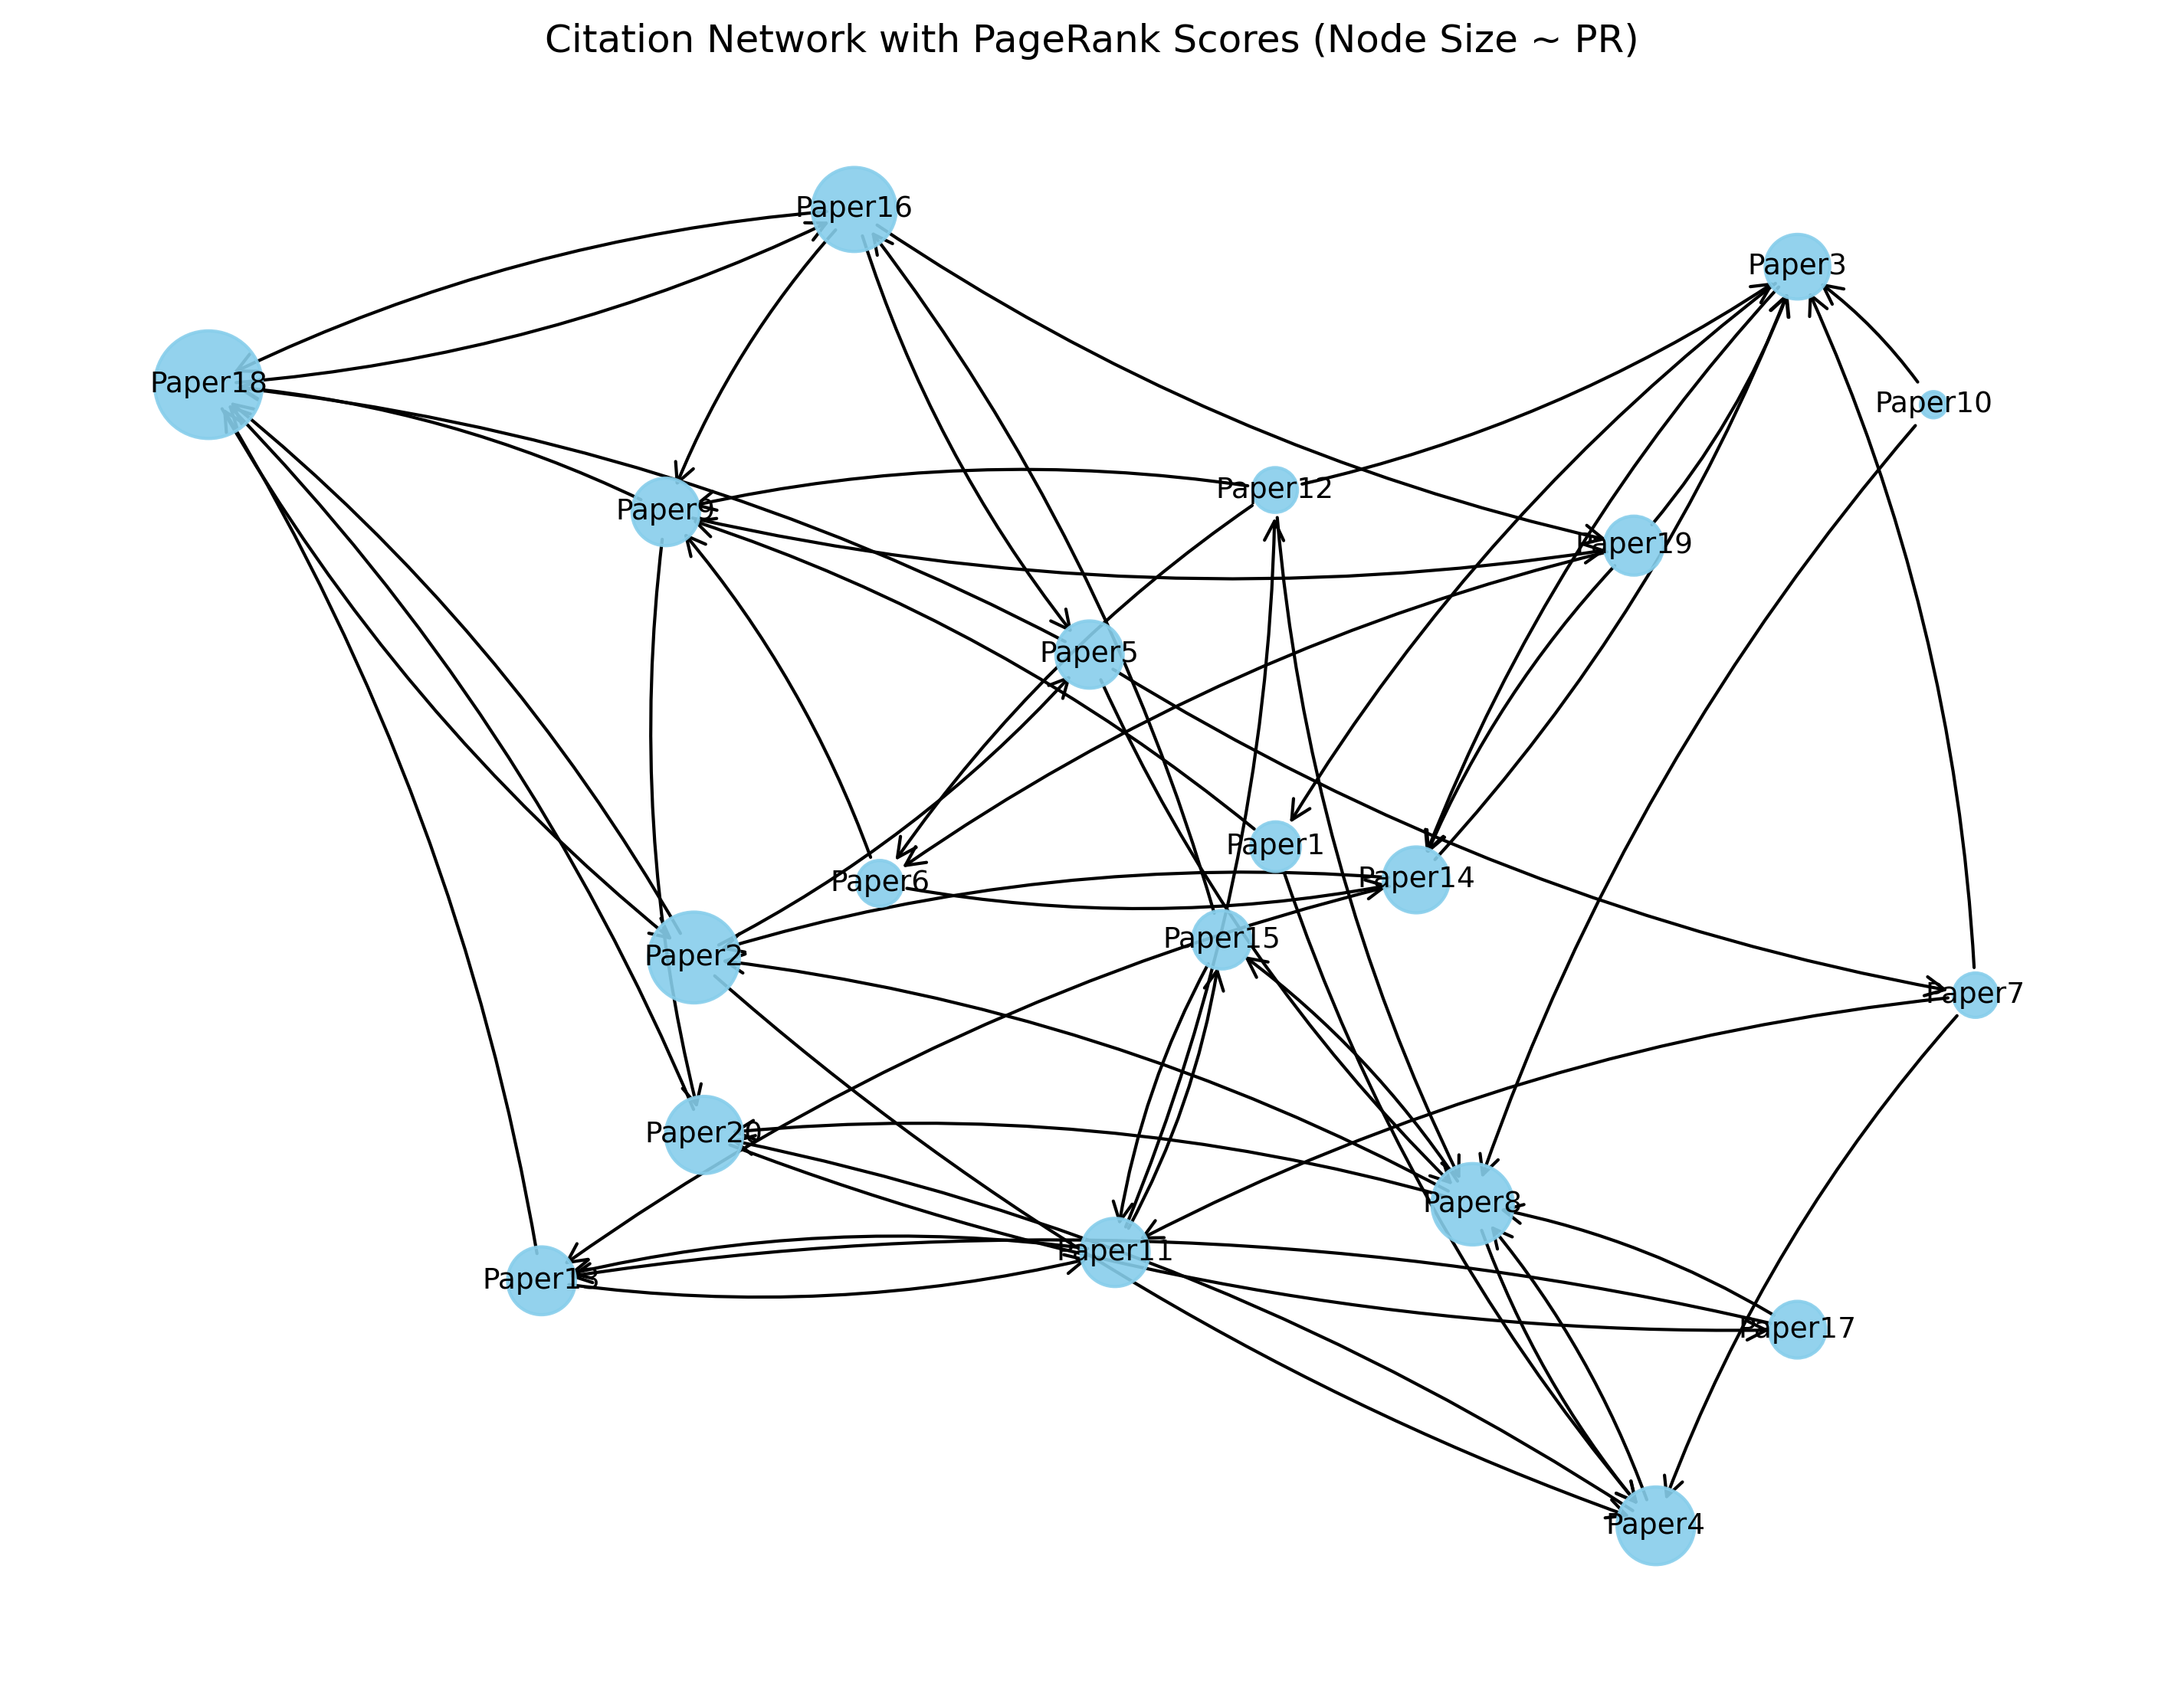

In [5]:
pos = nx.spring_layout(G, k=0.5, seed=42)
sizes = [9000 * pr_scores[n] for n in G.nodes()]  # scale by PR

plt.figure(figsize=(12,9), dpi=300)
nx.draw_networkx_nodes(G, pos, node_size=sizes, alpha=0.9, node_color="skyblue")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=15, connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Citation Network with PageRank Scores (Node Size ~ PR)")
plt.axis("off")
plt.show()
